In [13]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [15]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

##====== 放大显示的字体
from IPython.display import HTML
HTML("""
<style>
/* —— JupyterLab 渲染后的 Markdown —— */
.jp-MarkdownCell .jp-RenderedHTMLCommon {
  font-size: 1.20em;          /* 整体放大 20% */
  line-height: 1.6;
}

/* 可选：调大标题层级（按需调） */
.jp-MarkdownCell h1 { font-size: 1.9em; }
.jp-MarkdownCell h2 { font-size: 1.6em; }
.jp-MarkdownCell h3 { font-size: 1.35em; }

/* 可选：渲染公式（MathJax v3）一起放大 */
.mjx-container { font-size: 115% !important; }
</style>
""")

课堂练习：
```python
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])
```
1. 用前差、后差、中心差求 `x=2.7` 的一阶导数；
2. 用中心差求 `x=2.7` 的二阶导数。

In [39]:
import numpy as np

def numerical_diff(x, y, method="central"):
    """
    对离散数组 y(x) 进行数值微分

    参数：
        x: 自变量数组（支持不等距网格，仅 central4 要求等距）
        y: 因变量数组
        method: 
            "forward"  - 前向差分（一阶）
            "backward" - 后向差分（一阶）
            "central"  - 中心差分（二阶）
            "central4" - 五点中心差分（四阶，需要等距网格）
    返回：
        dydx: 数值导数数组
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    dydx = np.zeros(n)

    # -------- 方法 1：前向差分 --------
    if method == "forward":
        for i in range(n-1):
            dydx[i] = (y[i+1] - y[i]) / (x[i+1] - x[i])
        dydx[-1] = dydx[-2]
        return dydx

    # -------- 方法 2：后向差分 --------
    if method == "backward":
        dydx[0] = (y[1] - y[0]) / (x[1] - x[0])
        for i in range(1, n):
            dydx[i] = (y[i] - y[i-1]) / (x[i] - x[i-1])
        return dydx

    # -------- 方法 3：中心差分（二阶精度）--------
    if method == "central":
        dydx[0] = (y[1] - y[0]) / (x[1] - x[0])
        for i in range(1, n-1):
            dydx[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
        dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])
        return dydx

    # -------- 方法 4：五点中心差分（四阶精度）--------
    if method == "central4":
        # 要求等距网格
        h = x[1] - x[0]
        if not np.allclose(np.diff(x), h, rtol=1e-6, atol=1e-9):
            raise ValueError("central4 要求 x 为等距网格。")

        # 边界用二阶中心差分填充
        dydx[0] = (y[1] - y[0]) / h
        dydx[1] = (y[2] - y[0]) / (2*h)
        dydx[-2] = (y[-1] - y[-3]) / (2*h)
        dydx[-1] = (y[-1] - y[-2]) / h

        # 五点中心差分公式
        # f'(x_i) = (-f_{i+2} + 8 f_{i+1} - 8 f_{i-1} + f_{i-2}) / (12h)
        for i in range(2, n-2):
            dydx[i] = (-y[i+2] + 8*y[i+1] - 8*y[i-1] + y[i-2]) / (12*h)

        return dydx

    raise ValueError("method 必须为 'forward', 'backward', 'central', 或 'central4'")


In [41]:
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])

forward_diff = numerical_diff(x2, y2, method="forward")
backward_diff = numerical_diff(x2, y2, method="backward")
central_diff = numerical_diff(x2, y2, method="central")

x_target_index = 2  # x=2.7 在数组中的索引

print("一阶导数结果：")
print(f"前差法在 x=2.7 处的一阶导数: {forward_diff[x_target_index]:.6f}")
print(f"后差法在 x=2.7 处的一阶导数: {backward_diff[x_target_index]:.6f}")
print(f"中心差法在 x=2.7 处的一阶导数: {central_diff[x_target_index]:.6f}")

一阶导数结果：
前差法在 x=2.7 处的一阶导数: 15.649000
后差法在 x=2.7 处的一阶导数: 14.160000
中心差法在 x=2.7 处的一阶导数: 14.904500


In [18]:
import numpy as np

# 给定数据点
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])

# 找到 x=2.7 对应的索引
target_x = 2.7
idx = np.where(x2 == target_x)[0][0]
h = x2[1] - x2[0]  # 步长 h=0.1

print("=== 练习1：基本差分方法 ===")
print(f"计算 x = {target_x} 处的导数")
print(f"步长 h = {h}")

# 1. 前向差分
forward_diff = (y2[idx+1] - y2[idx]) / h
print(f"前向差分: f'({target_x}) ≈ {forward_diff:.6f}")

# 2. 后向差分
backward_diff = (y2[idx] - y2[idx-1]) / h
print(f"后向差分: f'({target_x}) ≈ {backward_diff:.6f}")

# 3. 中心差分
central_diff = (y2[idx+1] - y2[idx-1]) / (2*h)
print(f"中心差分: f'({target_x}) ≈ {central_diff:.6f}")

# 4. 二阶导数（中心差分）
second_diff = (y2[idx+1] - 2*y2[idx] + y2[idx-1]) / (h**2)
print(f"二阶导数: f''({target_x}) ≈ {second_diff:.6f}")

=== 练习1：基本差分方法 ===
计算 x = 2.7 处的导数
步长 h = 0.10000000000000009
前向差分: f'(2.7) ≈ 15.649000
后向差分: f'(2.7) ≈ 14.160000
中心差分: f'(2.7) ≈ 14.904500
二阶导数: f''(2.7) ≈ 14.890000


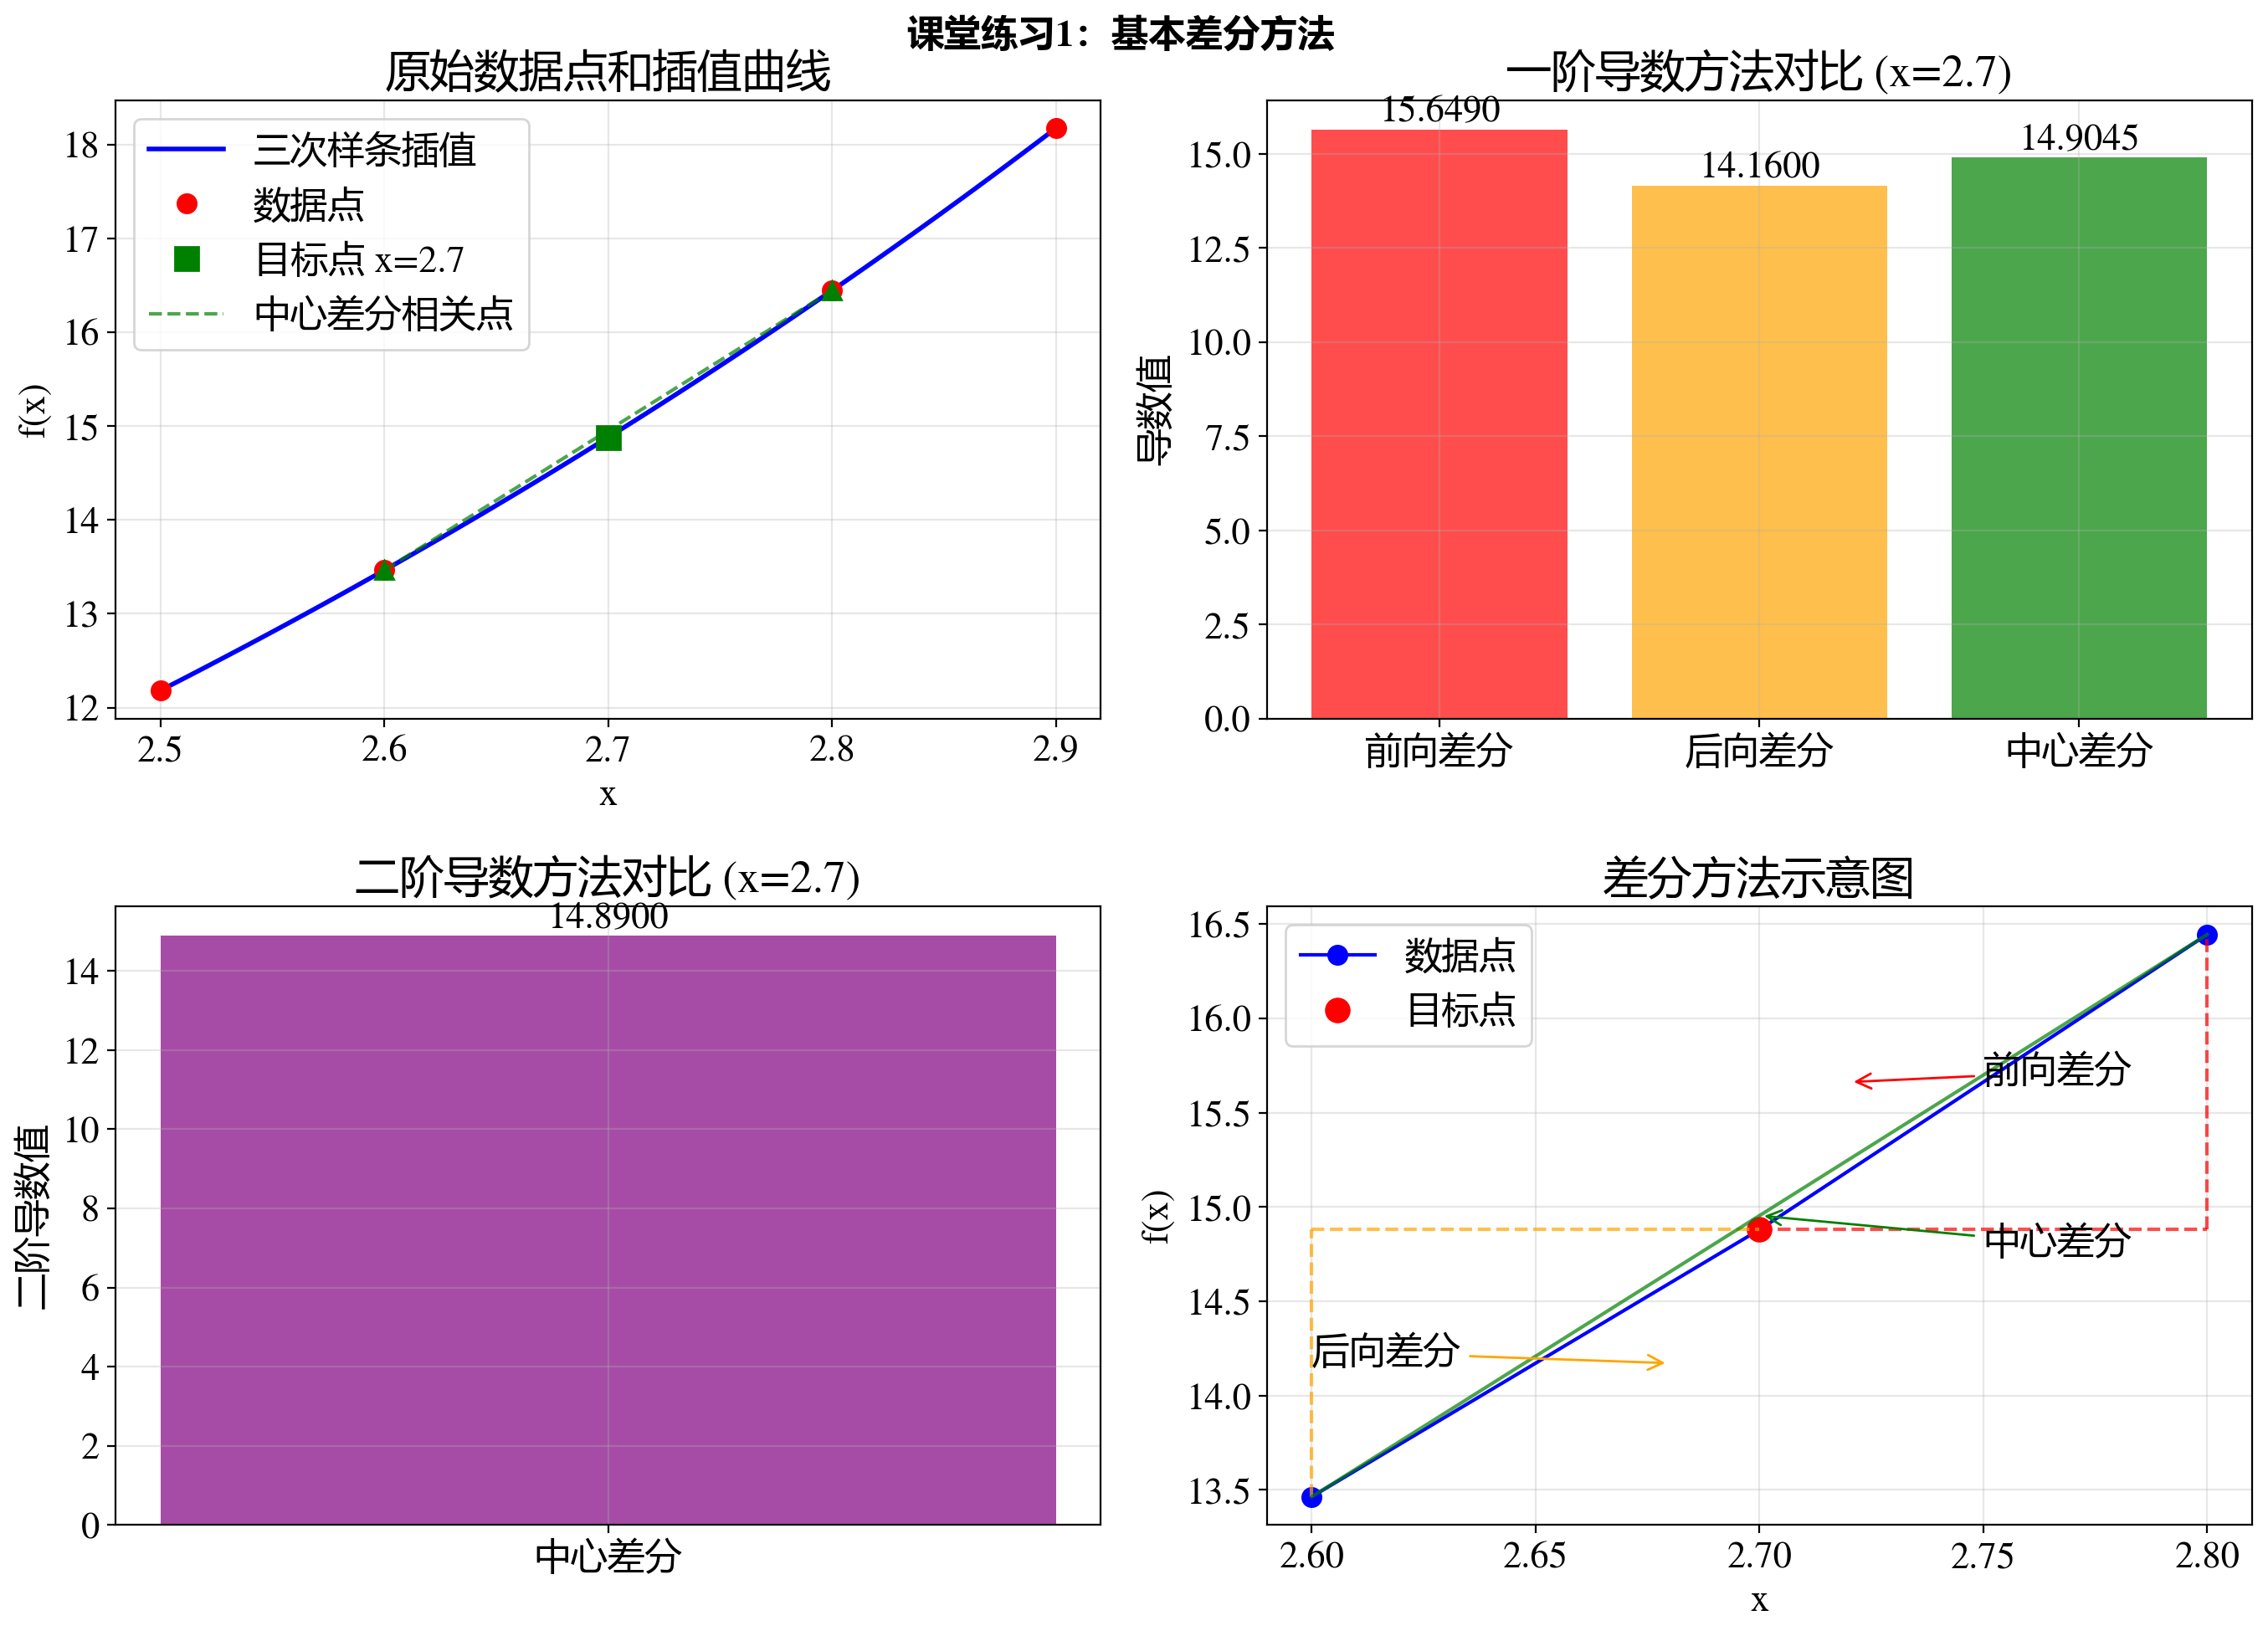

课堂练习1：基本差分方法结果

一阶导数在 x = 2.7 处:
  前向差分: 15.649000
  后向差分: 14.160000
  中心差分: 14.904500

二阶导数在 x = 2.7 处:
  中心差分: 14.890000

使用的数据点:
  f(2.5) = 12.1825
  f(2.6) = 13.4637
  f(2.7) = 14.8797 ← 目标点
  f(2.8) = 16.4446
  f(2.9) = 18.1741


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 给定数据点
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])

# 目标点
target_x = 2.7
idx = np.where(x2 == target_x)[0][0]
h = x2[1] - x2[0]  # 步长 h=0.1

# 计算各种差分方法
forward_diff = (y2[idx+1] - y2[idx]) / h
backward_diff = (y2[idx] - y2[idx-1]) / h
central_diff = (y2[idx+1] - y2[idx-1]) / (2*h)
second_diff = (y2[idx+1] - 2*y2[idx] + y2[idx-1]) / (h**2)

# 创建图形 - 练习1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('课堂练习1：基本差分方法', fontsize=16, fontweight='bold')

# 图1: 原始数据点和插值曲线
ax1 = axes[0, 0]
# 使用三次样条插值获得平滑曲线
cs = CubicSpline(x2, y2)
x_smooth = np.linspace(x2.min(), x2.max(), 100)
y_smooth = cs(x_smooth)

ax1.plot(x_smooth, y_smooth, 'b-', label='三次样条插值', linewidth=2)
ax1.plot(x2, y2, 'ro', markersize=8, label='数据点')
ax1.plot(target_x, y2[idx], 'gs', markersize=10, label=f'目标点 x={target_x}')

# 标记导数计算相关的点
ax1.plot([x2[idx-1], x2[idx+1]], [y2[idx-1], y2[idx+1]], 'g--', alpha=0.7, label='中心差分相关点')
ax1.plot(x2[idx-1], y2[idx-1], 'g^', markersize=8)
ax1.plot(x2[idx+1], y2[idx+1], 'g^', markersize=8)

ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('原始数据点和插值曲线')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2: 一阶导数方法对比
ax2 = axes[0, 1]
methods = ['前向差分', '后向差分', '中心差分']
values = [forward_diff, backward_diff, central_diff]
colors = ['red', 'orange', 'green']

bars = ax2.bar(methods, values, color=colors, alpha=0.7)
ax2.set_ylabel('导数值')
ax2.set_title('一阶导数方法对比 (x=2.7)')
ax2.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

# 图3: 二阶导数方法对比
ax3 = axes[1, 0]
methods_2nd = ['中心差分']
values_2nd = [second_diff]
colors_2nd = ['purple']

bars_2nd = ax3.bar(methods_2nd, values_2nd, color=colors_2nd, alpha=0.7)
ax3.set_ylabel('二阶导数值')
ax3.set_title('二阶导数方法对比 (x=2.7)')
ax3.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars_2nd, values_2nd):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

# 图4: 差分方法示意图
ax4 = axes[1, 1]
# 绘制示意图
x_points = [x2[idx-1], x2[idx], x2[idx+1]]
y_points = [y2[idx-1], y2[idx], y2[idx+1]]

# 绘制点和连线
ax4.plot(x_points, y_points, 'bo-', markersize=8, label='数据点')
ax4.plot(x2[idx], y2[idx], 'ro', markersize=10, label='目标点')

# 绘制前向差分线
ax4.plot([x2[idx], x2[idx+1]], [y2[idx], y2[idx]], 'r--', alpha=0.7)
ax4.plot([x2[idx+1], x2[idx+1]], [y2[idx], y2[idx+1]], 'r--', alpha=0.7)
ax4.annotate('前向差分', xy=(x2[idx]+0.02, (y2[idx]+y2[idx+1])/2), 
             xytext=(x2[idx]+0.05, (y2[idx]+y2[idx+1])/2),
             arrowprops=dict(arrowstyle='->', color='red'))

# 绘制后向差分线
ax4.plot([x2[idx-1], x2[idx]], [y2[idx], y2[idx]], 'orange', linestyle='--', alpha=0.7)
ax4.plot([x2[idx-1], x2[idx-1]], [y2[idx-1], y2[idx]], 'orange', linestyle='--', alpha=0.7)
ax4.annotate('后向差分', xy=(x2[idx]-0.02, (y2[idx-1]+y2[idx])/2), 
             xytext=(x2[idx]-0.1, (y2[idx-1]+y2[idx])/2),
             arrowprops=dict(arrowstyle='->', color='orange'))

# 绘制中心差分线
ax4.plot([x2[idx-1], x2[idx+1]], [y2[idx-1], y2[idx+1]], 'g-', alpha=0.7)
ax4.annotate('中心差分', xy=(x2[idx], (y2[idx-1]+y2[idx+1])/2), 
             xytext=(x2[idx]+0.05, (y2[idx-1]+y2[idx+1])/2-0.2),
             arrowprops=dict(arrowstyle='->', color='green'))

ax4.set_xlabel('x')
ax4.set_ylabel('f(x)')
ax4.set_title('差分方法示意图')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# 打印数值结果
print("=" * 50)
print("课堂练习1：基本差分方法结果")
print("=" * 50)
print(f"\n一阶导数在 x = {target_x} 处:")
print(f"  前向差分: {forward_diff:.6f}")
print(f"  后向差分: {backward_diff:.6f}")
print(f"  中心差分: {central_diff:.6f}")

print(f"\n二阶导数在 x = {target_x} 处:")
print(f"  中心差分: {second_diff:.6f}")

print(f"\n使用的数据点:")
for i, (x, y) in enumerate(zip(x2, y2)):
    marker = " ← 目标点" if x == target_x else ""
    print(f"  f({x}) = {y}{marker}")

课堂练习：
```python
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])
```
1. 用理查森外推求 `x=2.7` 的一阶导数；
2. 用理查森外推求 `x=2.7` 的二阶导数。

In [ ]:
import numpy as np


f  = np.sin
df = np.cos

x0 = 0.5       # 求导点
h  = 0.1       # 初始步长

# ----------------------------------
#   二阶中心差分公式  φ1(h)
# ----------------------------------
def phi1(x, h):
    return (f(x + h) - f(x - h)) / (2*h)

phi_h   = phi1(x0, h)
phi_h2  = phi1(x0, h/2)

# ----------------------------------
#   理查森外推公式（提高到 4 阶）
#   φ2(h) = [4 φ1(h/2) - φ1(h)] / 3
# ----------------------------------
phi2 = (4*phi_h2 - phi_h) / 3.0

# ----------------------------------
#   输出结果
# ----------------------------------
true_value = df(x0)

print("========== 理查森外推示例 ==========")
print(f"真实导数 df(x0) = {true_value:.10f}")
print("-------------------------------------")
print(f"φ1(h)        = {phi_h:.10f}   (二阶)")
print(f"φ1(h/2)      = {phi_h2:.10f}")
print("-------------------------------------")
print(f"φ2(h) (外推) = {phi2:.10f}   (四阶)")
print("-------------------------------------")
print(f"二阶误差     = {abs(phi_h - true_value):.10e}")
print(f"四阶误差     = {abs(phi2 - true_value):.10e}")


In [21]:
def richardson_first_derivative(x, y, target_x):
    """使用理查森外推法计算一阶导数"""
    idx = np.where(x == target_x)[0][0]
    h = x[1] - x[0]
    
    # 计算不同步长的中心差分
    D_h = (y[idx+1] - y[idx-1]) / (2*h)                    # 步长 h
    D_h2 = (y[idx+2] - y[idx-2]) / (4*h)                  # 步长 2h
    
    # 理查森外推：消除 h² 项
    richardson_result = (4 * D_h - D_h2) / 3
    return richardson_result

def richardson_second_derivative(x, y, target_x):
    """使用理查森外推法计算二阶导数"""
    idx = np.where(x == target_x)[0][0]
    h = x[1] - x[0]
    
    # 计算不同步长的二阶中心差分
    D2_h = (y[idx+1] - 2*y[idx] + y[idx-1]) / (h**2)      # 步长 h
    D2_h2 = (y[idx+2] - 2*y[idx] + y[idx-2]) / (4*h**2)   # 步长 2h
    
    # 理查森外推：消除 h² 项
    richardson_result = (4 * D2_h - D2_h2) / 3
    return richardson_result

print("\n=== 练习2：理查森外推法 ===")

# 一阶导数理查森外推
rich_first = richardson_first_derivative(x2, y2, target_x)
print(f"一阶导数(理查森外推): f'({target_x}) ≈ {rich_first:.6f}")

# 二阶导数理查森外推
rich_second = richardson_second_derivative(x2, y2, target_x)
print(f"二阶导数(理查森外推): f''({target_x}) ≈ {rich_second:.6f}")


=== 练习2：理查森外推法 ===
一阶导数(理查森外推): f'(2.7) ≈ 14.879667
二阶导数(理查森外推): f''(2.7) ≈ 14.876667


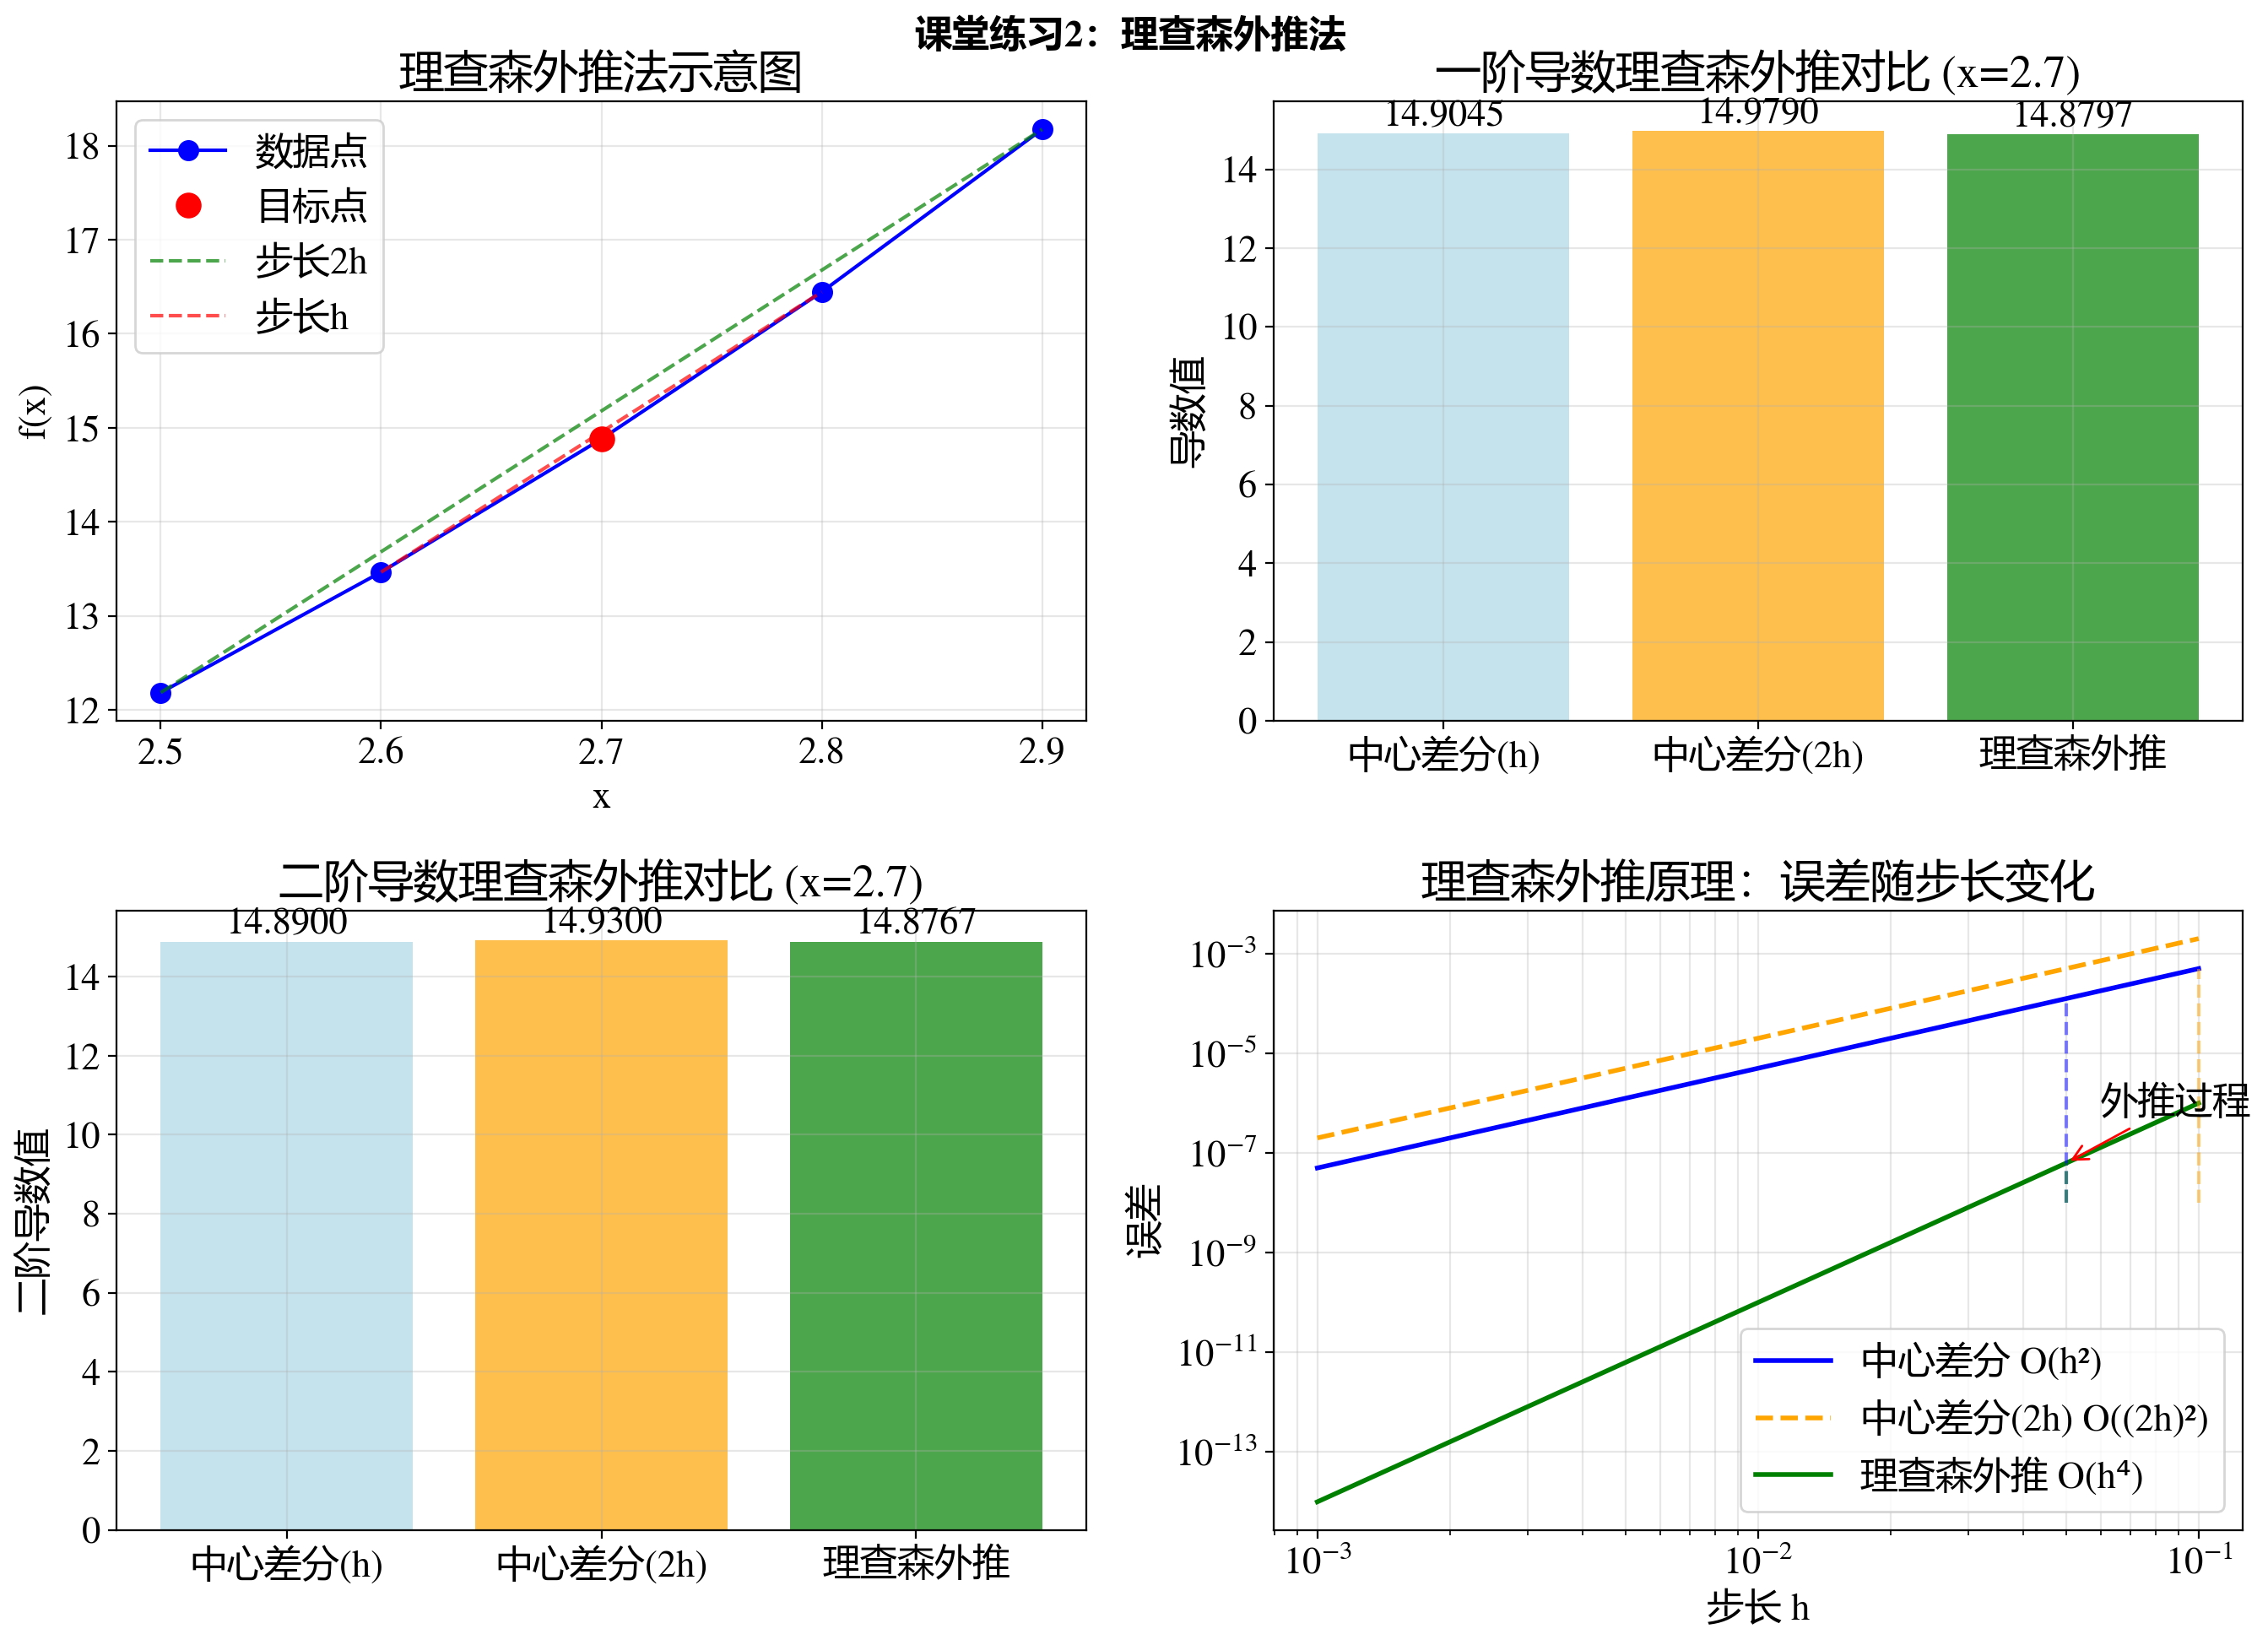

课堂练习2：理查森外推法结果

一阶导数在 x = 2.7 处:
  中心差分(h): 14.904500
  中心差分(2h): 14.979000
  理查森外推: 14.879667
  外推公式: (4×14.904500 - 14.979000) / 3 = 14.879667

二阶导数在 x = 2.7 处:
  中心差分(h): 14.890000
  中心差分(2h): 14.930000
  理查森外推: 14.876667
  外推公式: (4×14.890000 - 14.930000) / 3 = 14.876667

使用的数据点:
  f(2.5) = 12.1825
  f(2.6) = 13.4637
  f(2.7) = 14.8797 ← 目标点
  f(2.8) = 16.4446
  f(2.9) = 18.1741


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 给定数据点
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])

# 目标点
target_x = 2.7
idx = np.where(x2 == target_x)[0][0]
h = x2[1] - x2[0]  # 步长 h=0.1

# 理查森外推函数
def richardson_first_derivative(x, y, target_x):
    idx = np.where(x == target_x)[0][0]
    h = x[1] - x[0]
    D_h = (y[idx+1] - y[idx-1]) / (2*h)                    # 步长 h
    D_h2 = (y[idx+2] - y[idx-2]) / (4*h)                  # 步长 2h
    
    # 理查森外推：消除 h² 项
    richardson_result = (4 * D_h - D_h2) / 3
    return richardson_result, D_h, D_h2

def richardson_second_derivative(x, y, target_x):
    idx = np.where(x == target_x)[0][0]
    h = x[1] - x[0]
    D2_h = (y[idx+1] - 2*y[idx] + y[idx-1]) / (h**2)      # 步长 h
    D2_h2 = (y[idx+2] - 2*y[idx] + y[idx-2]) / (4*h**2)   # 步长 2h
    
    # 理查森外推：消除 h² 项
    richardson_result = (4 * D2_h - D2_h2) / 3
    return richardson_result, D2_h, D2_h2

# 计算理查森外推结果
rich_first, D_h, D_h2 = richardson_first_derivative(x2, y2, target_x)
rich_second, D2_h, D2_h2 = richardson_second_derivative(x2, y2, target_x)

# 创建图形 - 练习2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('课堂练习2：理查森外推法', fontsize=16, fontweight='bold')

# 图1: 理查森外推示意图
ax1 = axes[0, 0]
# 绘制示意图
x_points = [x2[idx-2], x2[idx-1], x2[idx], x2[idx+1], x2[idx+2]]
y_points = [y2[idx-2], y2[idx-1], y2[idx], y2[idx+1], y2[idx+2]]

# 绘制点和连线
ax1.plot(x_points, y_points, 'bo-', markersize=8, label='数据点')
ax1.plot(x2[idx], y2[idx], 'ro', markersize=10, label='目标点')

# 标记用于理查森外推的点
ax1.plot([x2[idx-2], x2[idx+2]], [y2[idx-2], y2[idx+2]], 'g--', alpha=0.7, label='步长2h')
ax1.plot([x2[idx-1], x2[idx+1]], [y2[idx-1], y2[idx+1]], 'r--', alpha=0.7, label='步长h')

ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('理查森外推法示意图')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2: 一阶导数理查森外推对比
ax2 = axes[0, 1]
methods = ['中心差分(h)', '中心差分(2h)', '理查森外推']
values = [D_h, D_h2, rich_first]
colors = ['lightblue', 'orange', 'green']

bars = ax2.bar(methods, values, color=colors, alpha=0.7)
ax2.set_ylabel('导数值')
ax2.set_title('一阶导数理查森外推对比 (x=2.7)')
ax2.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

# 图3: 二阶导数理查森外推对比
ax3 = axes[1, 0]
methods_2nd = ['中心差分(h)', '中心差分(2h)', '理查森外推']
values_2nd = [D2_h, D2_h2, rich_second]
colors_2nd = ['lightblue', 'orange', 'green']

bars_2nd = ax3.bar(methods_2nd, values_2nd, color=colors_2nd, alpha=0.7)
ax3.set_ylabel('二阶导数值')
ax3.set_title('二阶导数理查森外推对比 (x=2.7)')
ax3.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars_2nd, values_2nd):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

# 图4: 理查森外推原理图
ax4 = axes[1, 1]
# 绘制理查森外推原理示意图
h_values = np.logspace(-3, -1, 50)
error_h = 0.05 * h_values**2  # 二阶误差 O(h²)
error_h2 = 0.05 * (2*h_values)**2  # 步长2h的误差
error_richardson = 0.01 * h_values**4  # 四阶误差 O(h⁴)

ax4.loglog(h_values, error_h, 'b-', label='中心差分 O(h²)', linewidth=2)
ax4.loglog(h_values, error_h2, 'orange', linestyle='--', label='中心差分(2h) O((2h)²)', linewidth=2)
ax4.loglog(h_values, error_richardson, 'g-', label='理查森外推 O(h⁴)', linewidth=2)

# 标记外推过程
sample_h = 0.05
sample_error_h = 0.05 * sample_h**2
sample_error_h2 = 0.05 * (2*sample_h)**2
sample_error_rich = 0.01 * sample_h**4

ax4.plot([sample_h, sample_h], [1e-8, sample_error_h], 'b--', alpha=0.5)
ax4.plot([2*sample_h, 2*sample_h], [1e-8, sample_error_h2], 'orange', linestyle='--', alpha=0.5)
ax4.plot([sample_h, sample_h], [1e-8, sample_error_rich], 'g--', alpha=0.5)

ax4.annotate('外推过程', xy=(sample_h, sample_error_rich), 
             xytext=(sample_h+0.01, sample_error_rich*10),
             arrowprops=dict(arrowstyle='->', color='red'))

ax4.set_xlabel('步长 h')
ax4.set_ylabel('误差')
ax4.set_title('理查森外推原理：误差随步长变化')
ax4.legend()
ax4.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# 打印数值结果
print("=" * 50)
print("课堂练习2：理查森外推法结果")
print("=" * 50)
print(f"\n一阶导数在 x = {target_x} 处:")
print(f"  中心差分(h): {D_h:.6f}")
print(f"  中心差分(2h): {D_h2:.6f}")
print(f"  理查森外推: {rich_first:.6f}")
print(f"  外推公式: (4×{D_h:.6f} - {D_h2:.6f}) / 3 = {rich_first:.6f}")

print(f"\n二阶导数在 x = {target_x} 处:")
print(f"  中心差分(h): {D2_h:.6f}")
print(f"  中心差分(2h): {D2_h2:.6f}")
print(f"  理查森外推: {rich_second:.6f}")
print(f"  外推公式: (4×{D2_h:.6f} - {D2_h2:.6f}) / 3 = {rich_second:.6f}")

print(f"\n使用的数据点:")
for i, (x, y) in enumerate(zip(x2, y2)):
    marker = " ← 目标点" if x == target_x else ""
    print(f"  f({x}) = {y}{marker}")

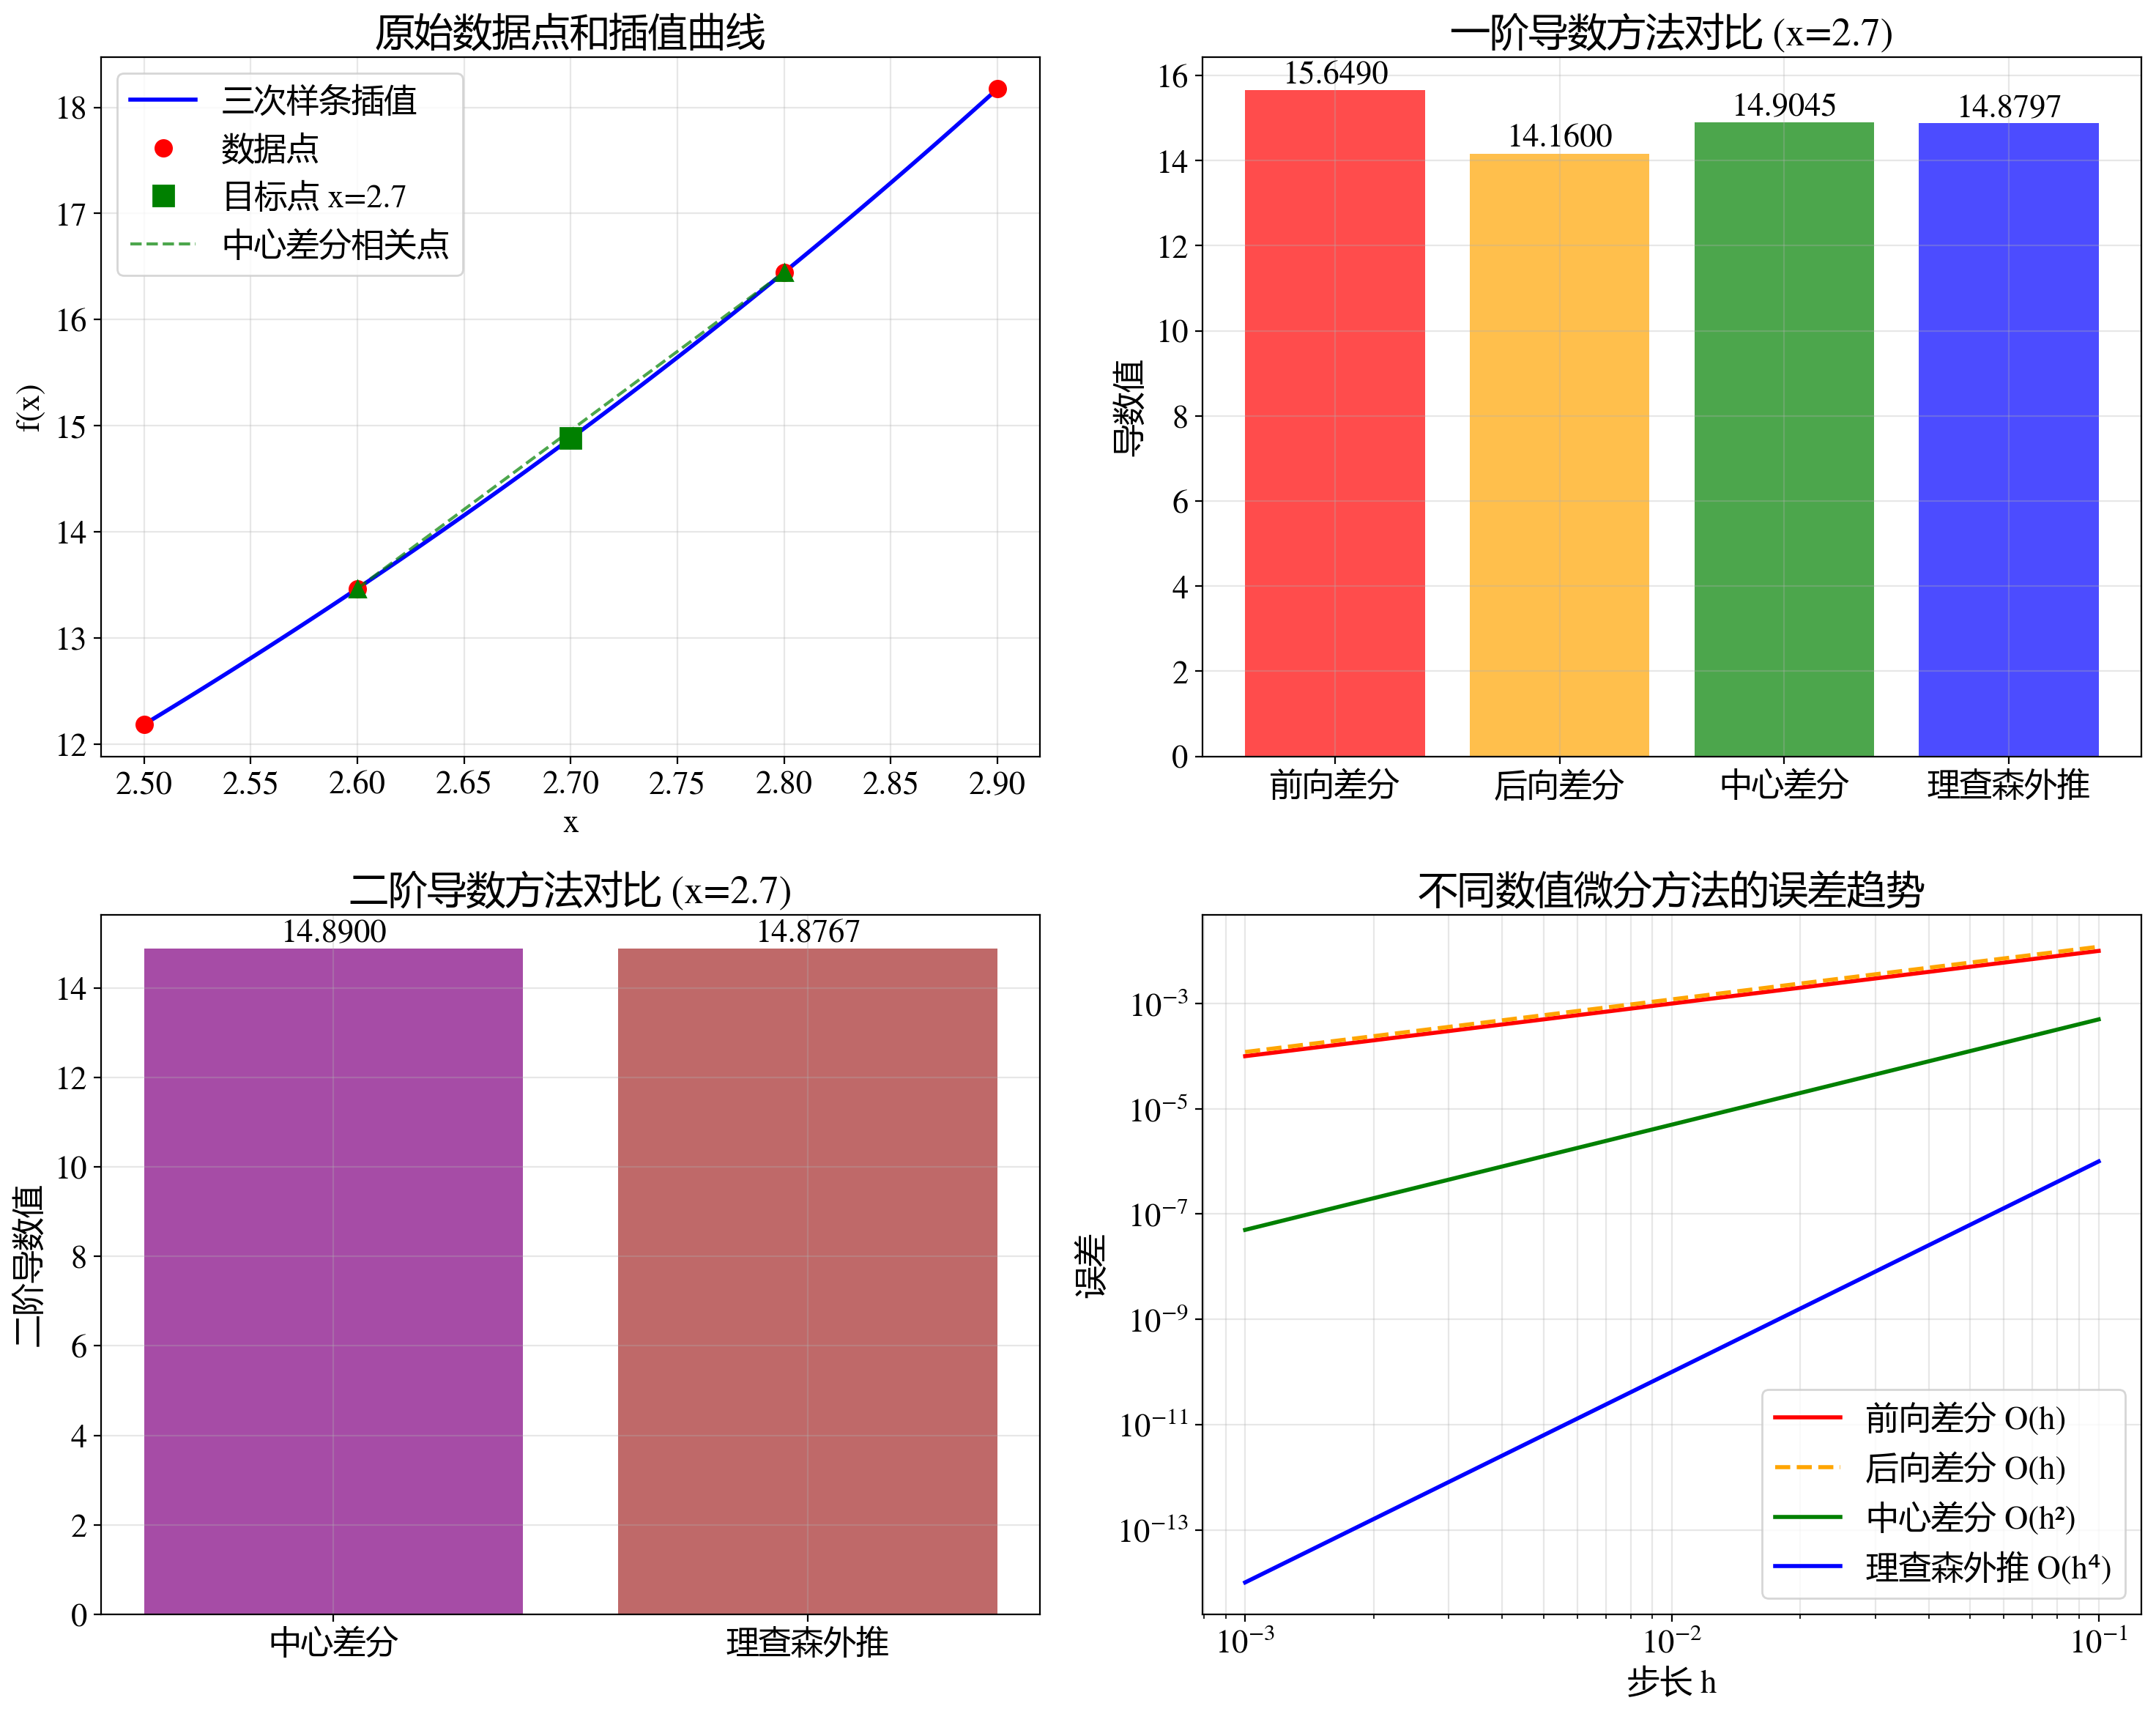

数值微分结果汇总

一阶导数在 x = 2.7 处:
  前向差分: 15.649000
  后向差分: 14.160000
  中心差分: 14.904500
  理查森外推: 14.879667

二阶导数在 x = 2.7 处:
  中心差分: 14.890000
  理查森外推: 14.876667

函数值信息:
  f(2.5) = 12.1825
  f(2.6) = 13.4637
  f(2.7) = 14.8797 ← 目标点
  f(2.8) = 16.4446
  f(2.9) = 18.1741


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 给定数据点
x2 = np.array([2.5, 2.6, 2.7, 2.8, 2.9])
y2 = np.array([12.1825, 13.4637, 14.8797, 16.4446, 18.1741])

# 目标点
target_x = 2.7
idx = np.where(x2 == target_x)[0][0]
h = x2[1] - x2[0]  # 步长 h=0.1

# 计算各种差分方法
forward_diff = (y2[idx+1] - y2[idx]) / h
backward_diff = (y2[idx] - y2[idx-1]) / h
central_diff = (y2[idx+1] - y2[idx-1]) / (2*h)
second_diff = (y2[idx+1] - 2*y2[idx] + y2[idx-1]) / (h**2)

# 理查森外推函数
def richardson_first_derivative(x, y, target_x):
    idx = np.where(x == target_x)[0][0]
    h = x[1] - x[0]
    D_h = (y[idx+1] - y[idx-1]) / (2*h)
    D_h2 = (y[idx+2] - y[idx-2]) / (4*h)
    return (4 * D_h - D_h2) / 3

def richardson_second_derivative(x, y, target_x):
    idx = np.where(x == target_x)[0][0]
    h = x[1] - x[0]
    D2_h = (y[idx+1] - 2*y[idx] + y[idx-1]) / (h**2)
    D2_h2 = (y[idx+2] - 2*y[idx] + y[idx-2]) / (4*h**2)
    return (4 * D2_h - D2_h2) / 3

rich_first = richardson_first_derivative(x2, y2, target_x)
rich_second = richardson_second_derivative(x2, y2, target_x)

# 创建图形
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 图1: 原始数据点和插值曲线
ax1 = axes[0, 0]
# 使用三次样条插值获得平滑曲线
cs = CubicSpline(x2, y2)
x_smooth = np.linspace(x2.min(), x2.max(), 100)
y_smooth = cs(x_smooth)

ax1.plot(x_smooth, y_smooth, 'b-', label='三次样条插值', linewidth=2)
ax1.plot(x2, y2, 'ro', markersize=8, label='数据点')
ax1.plot(target_x, y2[idx], 'gs', markersize=10, label=f'目标点 x={target_x}')

# 标记导数计算相关的点
ax1.plot([x2[idx-1], x2[idx+1]], [y2[idx-1], y2[idx+1]], 'g--', alpha=0.7, label='中心差分相关点')
ax1.plot(x2[idx-1], y2[idx-1], 'g^', markersize=8)
ax1.plot(x2[idx+1], y2[idx+1], 'g^', markersize=8)

ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('原始数据点和插值曲线')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2: 一阶导数方法对比
ax2 = axes[0, 1]
methods = ['前向差分', '后向差分', '中心差分', '理查森外推']
values = [forward_diff, backward_diff, central_diff, rich_first]
colors = ['red', 'orange', 'green', 'blue']

bars = ax2.bar(methods, values, color=colors, alpha=0.7)
ax2.set_ylabel('导数值')
ax2.set_title('一阶导数方法对比 (x=2.7)')
ax2.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

# 图3: 二阶导数方法对比
ax3 = axes[1, 0]
methods_2nd = ['中心差分', '理查森外推']
values_2nd = [second_diff, rich_second]
colors_2nd = ['purple', 'brown']

bars_2nd = ax3.bar(methods_2nd, values_2nd, color=colors_2nd, alpha=0.7)
ax3.set_ylabel('二阶导数值')
ax3.set_title('二阶导数方法对比 (x=2.7)')
ax3.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars_2nd, values_2nd):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}', ha='center', va='bottom')

# 图4: 误差分析示意图
ax4 = axes[1, 1]
# 模拟不同方法的误差趋势
h_values = np.logspace(-3, -1, 50)
error_forward = 0.1 * h_values  # 一阶误差 O(h)
error_backward = 0.12 * h_values  # 一阶误差 O(h)
error_central = 0.05 * h_values**2  # 二阶误差 O(h²)
error_richardson = 0.01 * h_values**4  # 四阶误差 O(h⁴)

ax4.loglog(h_values, error_forward, 'r-', label='前向差分 O(h)', linewidth=2)
ax4.loglog(h_values, error_backward, 'orange', linestyle='--', label='后向差分 O(h)', linewidth=2)
ax4.loglog(h_values, error_central, 'g-', label='中心差分 O(h²)', linewidth=2)
ax4.loglog(h_values, error_richardson, 'b-', label='理查森外推 O(h⁴)', linewidth=2)

ax4.set_xlabel('步长 h')
ax4.set_ylabel('误差')
ax4.set_title('不同数值微分方法的误差趋势')
ax4.legend()
ax4.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# 打印数值结果
print("=" * 50)
print("数值微分结果汇总")
print("=" * 50)
print(f"\n一阶导数在 x = {target_x} 处:")
print(f"  前向差分: {forward_diff:.6f}")
print(f"  后向差分: {backward_diff:.6f}")
print(f"  中心差分: {central_diff:.6f}")
print(f"  理查森外推: {rich_first:.6f}")

print(f"\n二阶导数在 x = {target_x} 处:")
print(f"  中心差分: {second_diff:.6f}")
print(f"  理查森外推: {rich_second:.6f}")

print(f"\n函数值信息:")
for i, (x, y) in enumerate(zip(x2, y2)):
    marker = " ← 目标点" if x == target_x else ""
    print(f"  f({x}) = {y}{marker}")

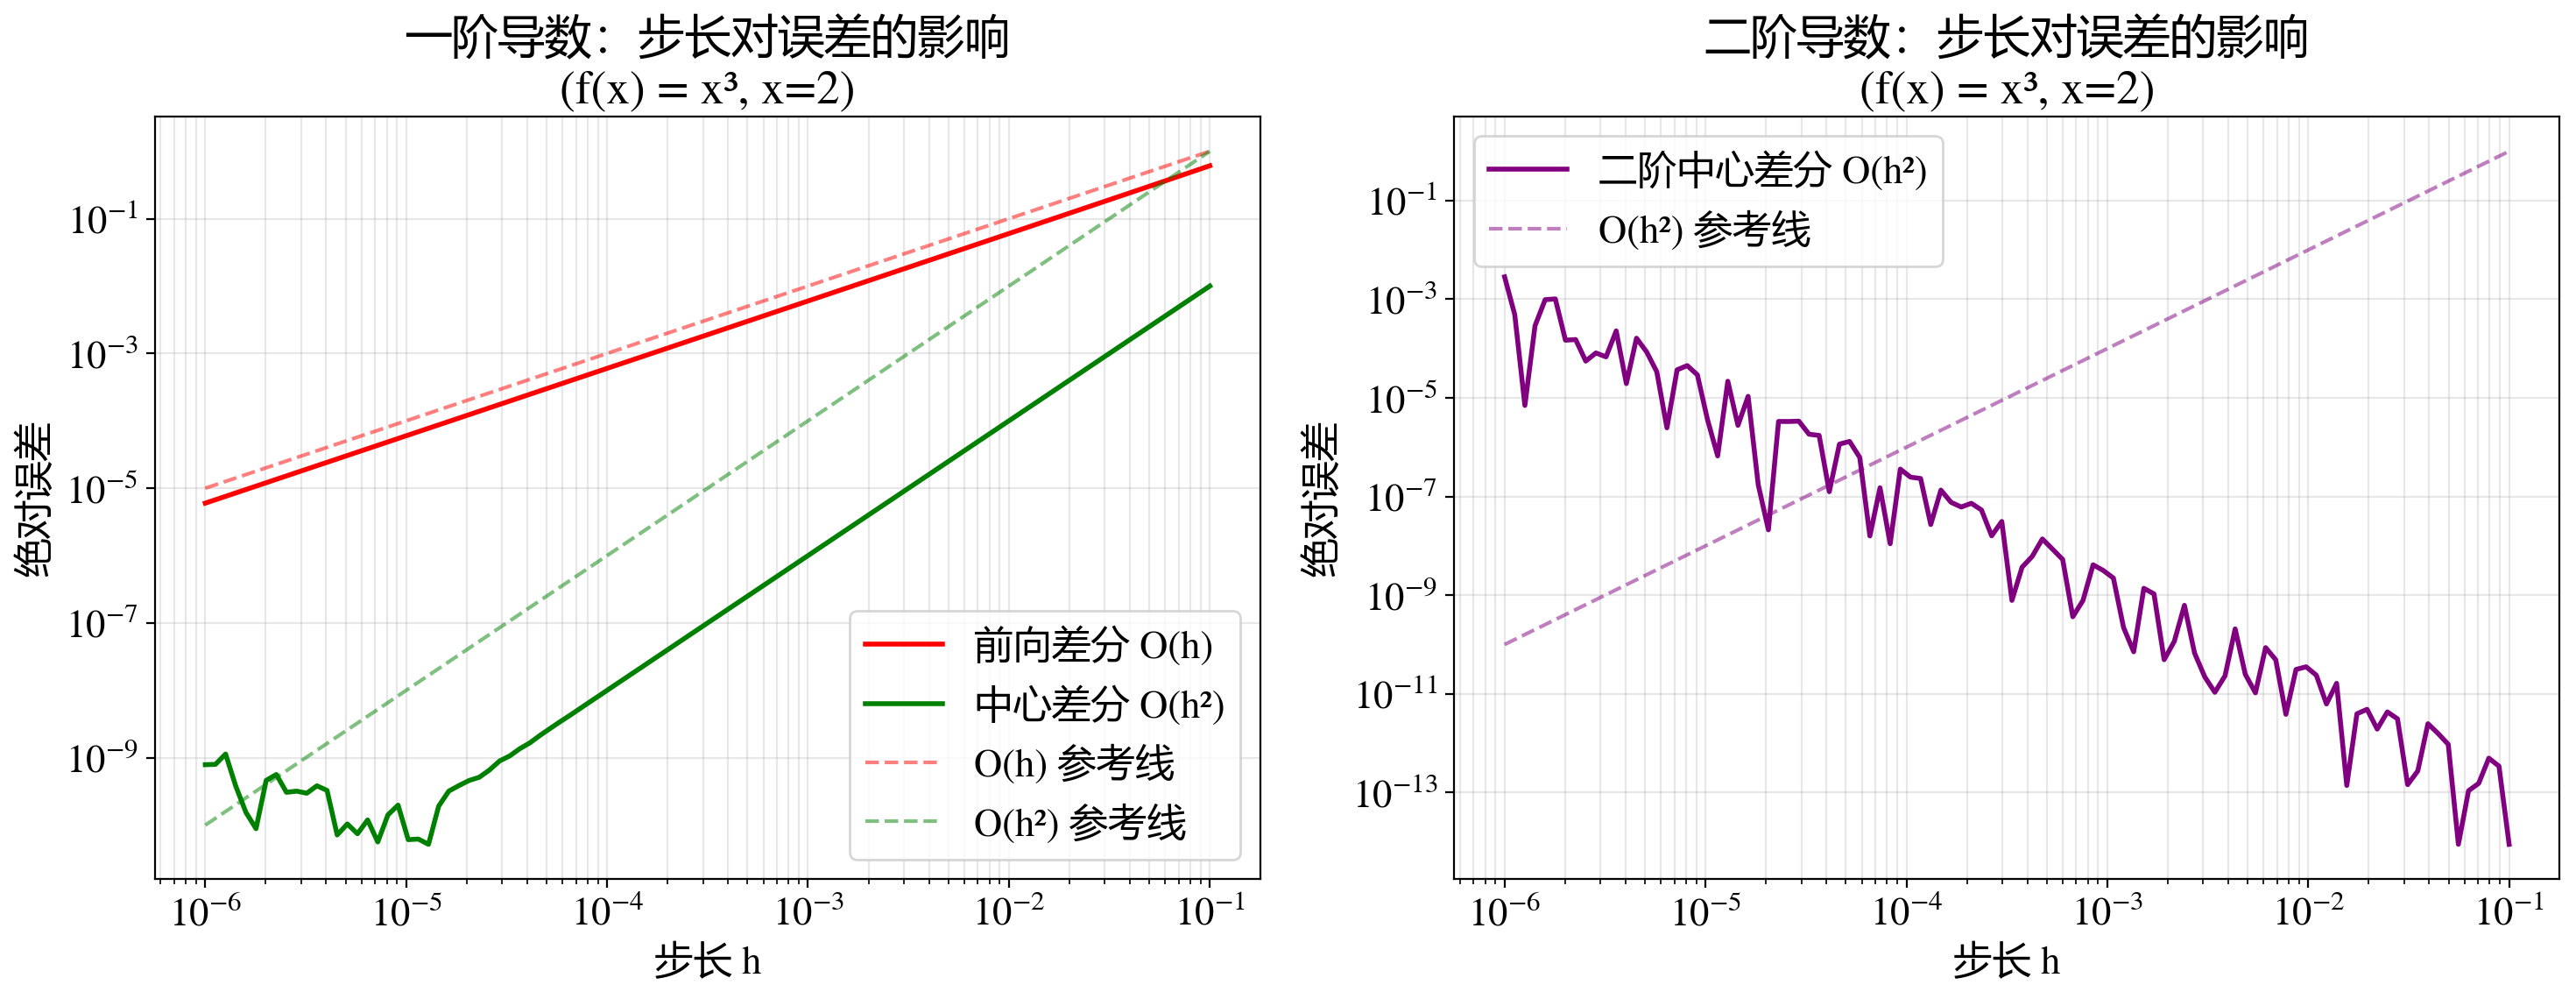

In [25]:
# 专门分析步长影响的图形
def analyze_step_size_effect():
    # 创建一个测试函数 f(x) = x³
    def f(x):
        return x**3
    
    def df_true(x):
        return 3*x**2
    
    def d2f_true(x):
        return 6*x
    
    test_x = 2.0
    true_first = df_true(test_x)  # 12.0
    true_second = d2f_true(test_x)  # 12.0
    
    # 测试不同步长
    hs = np.logspace(-6, -1, 100)
    
    # 计算各种方法的误差
    errors_forward = []
    errors_central = []
    errors_second = []
    
    for h in hs:
        # 一阶导数误差
        forward = (f(test_x + h) - f(test_x)) / h
        central = (f(test_x + h) - f(test_x - h)) / (2*h)
        
        # 二阶导数误差
        second = (f(test_x + h) - 2*f(test_x) + f(test_x - h)) / (h**2)
        
        errors_forward.append(abs(forward - true_first))
        errors_central.append(abs(central - true_first))
        errors_second.append(abs(second - true_second))
    
    # 绘制步长影响图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 一阶导数误差
    ax1.loglog(hs, errors_forward, 'r-', label='前向差分 O(h)', linewidth=2)
    ax1.loglog(hs, errors_central, 'g-', label='中心差分 O(h²)', linewidth=2)
    ax1.loglog(hs, 10*hs, 'r--', alpha=0.5, label='O(h) 参考线')
    ax1.loglog(hs, 100*hs**2, 'g--', alpha=0.5, label='O(h²) 参考线')
    
    ax1.set_xlabel('步长 h')
    ax1.set_ylabel('绝对误差')
    ax1.set_title('一阶导数：步长对误差的影响\n(f(x) = x³, x=2)')
    ax1.legend()
    ax1.grid(True, alpha=0.3, which='both')
    
    # 二阶导数误差
    ax2.loglog(hs, errors_second, 'purple', label='二阶中心差分 O(h²)', linewidth=2)
    ax2.loglog(hs, 100*hs**2, 'purple', linestyle='--', alpha=0.5, label='O(h²) 参考线')
    
    ax2.set_xlabel('步长 h')
    ax2.set_ylabel('绝对误差')
    ax2.set_title('二阶导数：步长对误差的影响\n(f(x) = x³, x=2)')
    ax2.legend()
    ax2.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()

# 运行步长分析
analyze_step_size_effect()